# 08 — Base e Dimensão
**Referência:** Boldrini et al., Seção 4.6, p. 116–129

---

## 8.1 Definição de Base (Boldrini, p. 116)

Um conjunto $\mathcal{B} = \{v_1, \ldots, v_n\}$ é uma **base** de $V$ se:

1. $\mathcal{B}$ é **LI**
2. $\mathcal{B}$ **gera** $V$, ou seja, $[v_1, \ldots, v_n] = V$

Equivalentemente: todo vetor de $V$ pode ser escrito de forma **única** como CL dos vetores de $\mathcal{B}$.

---

## 8.2 Dimensão (Boldrini, p. 120)

Quaisquer duas bases de $V$ têm sempre o **mesmo número de elementos**. Esse número é a **dimensão** $\dim(V)$.

---

## 8.3 Bases Canônicas

| Espaço | Base Canônica | Dimensão |
|--------|---------------|----------|
| $\mathbb{R}^n$ | $\{e_1, e_2, \ldots, e_n\}$ | $n$ |
| $M(m,n)$ | Matrizes com um único $1$ | $m \cdot n$ |
| $P_n$ | $\{1, x, x^2, \ldots, x^n\}$ | $n+1$ |

---

## 8.4 Propriedades (Boldrini, p. 119–121)

Seja $\dim(V) = n$:
- Qualquer conjunto com **mais de $n$** vetores é **LD**
- Qualquer conjunto **LI** com $n$ vetores é **base**
- Qualquer conjunto com $n$ vetores que **gera** $V$ é **base**
- $W$ subespaço $\Rightarrow \dim(W) \leq \dim(V)$


In [6]:
from sympy import Matrix, pprint, eye
from sympy import init_printing
init_printing(use_unicode=True)

def base_e_dimensao(vetores, nome="W"):
    '''Encontra base e dimensao de span dos vetores via escalonamento.'''
    M = Matrix(vetores)   # vetores como linhas
    rref_m, pivs = M.rref()
    dim = M.rank()
    base = [list(rref_m.row(i)) for i in range(dim)]
    print(f"span{{{nome}}}:")
    print(f"  Matriz original:"); pprint(M)
    print(f"  RREF:"); pprint(rref_m)
    print(f"  Dimensão = {dim}")
    print(f"  Base: {base}")
    return base, dim

# ── Exemplo do trabalho ───────────────────────────────
print("─── Exemplo 8.2: W = [(1,1,0),(0,1,1),(1,2,1)] ───\n")
base_e_dimensao([[1,1,0],[0,1,1],[1,2,1]], "(1,1,0),(0,1,1),(1,2,1)")


─── Exemplo 8.2: W = [(1,1,0),(0,1,1),(1,2,1)] ───

span{(1,1,0),(0,1,1),(1,2,1)}:
  Matriz original:
⎡1  1  0⎤
⎢       ⎥
⎢0  1  1⎥
⎢       ⎥
⎣1  2  1⎦
  RREF:
⎡1  0  -1⎤
⎢        ⎥
⎢0  1  1 ⎥
⎢        ⎥
⎣0  0  0 ⎦
  Dimensão = 2
  Base: [[1, 0, -1], [0, 1, 1]]


In [7]:
# ── Bases canônicas ──────────────────────────────────
print("─── Bases Canônicas ───\n")

print("Base canônica de R³:")
for i, e in enumerate([Matrix([1,0,0]), Matrix([0,1,0]), Matrix([0,0,1])], 1):
    print(f"  e{i} = {e.T}")
print(f"  dim(R³) = 3\n")

print("Base canônica de M(2,2):")
for i in range(2):
    for j in range(2):
        E = Matrix([[1 if (r==i and c==j) else 0 for c in range(2)] for r in range(2)])
        print(f"  E_{i+1}{j+1} =", end=" "); pprint(E)
print(f"  dim(M(2,2)) = 4\n")

print("Base canônica de P_2: {1, x, x²}")
print("  dim(P_2) = 3")


─── Bases Canônicas ───

Base canônica de R³:
  e1 = Matrix([[1, 0, 0]])
  e2 = Matrix([[0, 1, 0]])
  e3 = Matrix([[0, 0, 1]])
  dim(R³) = 3

Base canônica de M(2,2):
  E_11 = ⎡1  0⎤
⎢    ⎥
⎣0  0⎦
  E_12 = ⎡0  1⎤
⎢    ⎥
⎣0  0⎦
  E_21 = ⎡0  0⎤
⎢    ⎥
⎣1  0⎦
  E_22 = ⎡0  0⎤
⎢    ⎥
⎣0  1⎦
  dim(M(2,2)) = 4

Base canônica de P_2: {1, x, x²}
  dim(P_2) = 3


In [8]:
# ── Verificação: LI + gera → base ────────────────────
from sympy import Matrix

print("─── Verificando se {(1,1),(0,1)} é base de R² ───")
v1 = Matrix([1,1]); v2 = Matrix([0,1])
M = v1.row_join(v2)

li = M.rank() == 2
print(f"LI? posto={M.rank()}, n=2 → {li}")

# Gera R²? qualquer (x,y) = α(1,1) + β(0,1)?
from sympy import symbols, linsolve
x, y, a, b = symbols('x y alpha beta')
# sistema: α + 0β = x, α + β = y → solúvel para quaisquer x,y?
print(f"Gera R²? det={M.det()} ≠ 0 → {M.det() != 0}")
print(f"\n✅ {{(1,1),(0,1)}} é base de R²!")


─── Verificando se {(1,1),(0,1)} é base de R² ───
LI? posto=2, n=2 → True
Gera R²? det=1 ≠ 0 → True

✅ {(1,1),(0,1)} é base de R²!


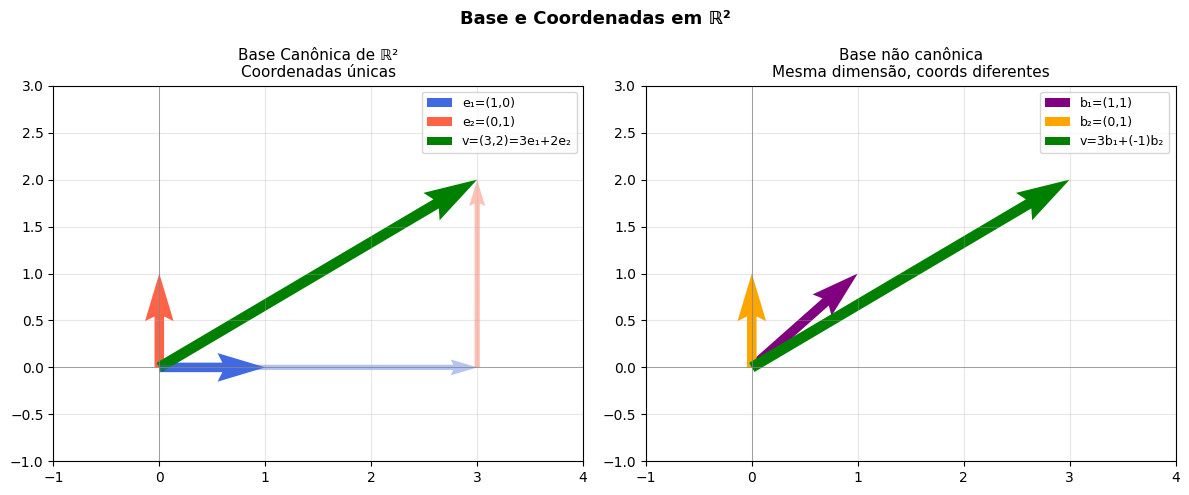

In [9]:
# ── Visualização: base e coordenadas ─────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
origin = np.array([0, 0])

# Base canônica
ax = axes[0]
e1, e2 = np.array([1,0]), np.array([0,1])
v = np.array([3, 2])
ax.quiver(*origin, *e1, color='royalblue', angles='xy', scale_units='xy', scale=1, width=0.018, label='e₁=(1,0)')
ax.quiver(*origin, *e2, color='tomato', angles='xy', scale_units='xy', scale=1, width=0.018, label='e₂=(0,1)')
ax.quiver(*origin, *v,  color='green', angles='xy', scale_units='xy', scale=1, width=0.02, label='v=(3,2)=3e₁+2e₂')
ax.quiver(*origin, *3*e1, color='royalblue', angles='xy', scale_units='xy', scale=1, width=0.01, alpha=0.4)
ax.quiver(*3*e1, *2*e2, color='tomato', angles='xy', scale_units='xy', scale=1, width=0.01, alpha=0.4)
ax.set_xlim(-1, 4); ax.set_ylim(-1, 3)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
ax.set_title('Base Canônica de ℝ²\nCoordenadas únicas', fontsize=11)

# Base não canônica
ax = axes[1]
b1, b2 = np.array([1,1]), np.array([0,1])
# v = α*b1 + β*b2: (3,2) = 3*(1,1) + (-1)*(0,1)
a_val, b_val = 3, -1
ax.quiver(*origin, *b1, color='purple', angles='xy', scale_units='xy', scale=1, width=0.018, label='b₁=(1,1)')
ax.quiver(*origin, *b2, color='orange', angles='xy', scale_units='xy', scale=1, width=0.018, label='b₂=(0,1)')
ax.quiver(*origin, *v,  color='green', angles='xy', scale_units='xy', scale=1, width=0.02, label=f'v=3b₁+({b_val})b₂')
ax.set_xlim(-1, 4); ax.set_ylim(-1, 3)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
ax.set_title('Base não canônica\nMesma dimensão, coords diferentes', fontsize=11)

plt.suptitle('Base e Coordenadas em ℝ²', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 📝 Exercícios

1. Encontre uma base e a dimensão de $W = \{(x,y,z) : x+y+z=0\}$.
2. Mostre que $\{(1,0,1),(0,1,0),(1,1,1)\}$ é base de $\mathbb{R}^3$.
3. Qual é a dimensão de $M(3,2)$? Escreva a base canônica.


In [10]:
from sympy import Matrix, symbols, linsolve

# Ex. 1: W = {x+y+z=0} — parametrizar
# x = -y - z, então (x,y,z) = y(-1,1,0) + z(-1,0,1)
print("Ex.1: W = {x+y+z=0}")
print("  parametrização: y(-1,1,0) + z(-1,0,1)")
base, dim = base_e_dimensao([[-1,1,0],[-1,0,1]], "W")

# Ex. 2
print("\nEx.2: {(1,0,1),(0,1,0),(1,1,1)} é base de R³?")
M = Matrix([[1,0,1],[0,1,0],[1,1,1]]).T
print(f"  posto = {M.rank()} = 3 = dim(R³)  → ✓ É base!")

# Ex. 3
print("\nEx.3: dim(M(3,2)) = 3×2 = 6")


Ex.1: W = {x+y+z=0}
  parametrização: y(-1,1,0) + z(-1,0,1)
span{W}:
  Matriz original:
⎡-1  1  0⎤
⎢        ⎥
⎣-1  0  1⎦
  RREF:
⎡1  0  -1⎤
⎢        ⎥
⎣0  1  -1⎦
  Dimensão = 2
  Base: [[1, 0, -1], [0, 1, -1]]

Ex.2: {(1,0,1),(0,1,0),(1,1,1)} é base de R³?
  posto = 2 = 3 = dim(R³)  → ✓ É base!

Ex.3: dim(M(3,2)) = 3×2 = 6
